# Jackal MJCF / mjSpec Test

This notebook focuses on the local Jackal scene XML used by the MJX env. It parses the XML with `mjSpec`, compiles it, inspects the model, and lets you save edited XML back out.

This notebook defaults to `MUJOCO_GL=osmesa`, which renders correctly on this machine. If your setup has working EGL instead, you can switch it back in the first code cell.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MUJOCO_GL", "osmesa")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import mujoco as mj
import mediapy as media
import numpy as np

JACKAL_SCENE_PATH = Path("ss2r/benchmark_suites/mujoco_playground/jackal_joystick/assets/xmls/scene_mjx_flat_terrain.xml")
JACKAL_SCENE_PATH


PosixPath('ss2r/benchmark_suites/mujoco_playground/jackal_joystick/assets/xmls/scene_mjx_flat_terrain.xml')

In [2]:
spec = mj.MjSpec.from_file(JACKAL_SCENE_PATH.as_posix())
model = spec.compile()
data = mj.MjData(model)

print("model:", model.nbody, "bodies /", model.ngeom, "geoms /", model.nu, "actuators /", model.nsensor, "sensors")


model: 8 bodies / 12 geoms / 4 actuators / 6 sensors


In [3]:
{
    "bodies": [model.body(i).name for i in range(model.nbody)],
    "geoms": [model.geom(i).name for i in range(model.ngeom)],
    "joints": [model.joint(i).name for i in range(model.njnt)],
    "actuators": [model.actuator(i).name for i in range(model.nu)],
    "sensors": [model.sensor(i).name for i in range(model.nsensor)],
}


{'bodies': ['world',
  'base_link',
  'chassis_link',
  'front_left_wheel_link',
  'front_right_wheel_link',
  'rear_left_wheel_link',
  'rear_right_wheel_link',
  'imu_link'],
 'geoms': ['floor',
  'chassis_collision',
  'chassis_visual',
  'front_fender',
  'rear_fender',
  'top_plate',
  'front_mount_geom',
  'rear_mount_geom',
  'front_left_wheel',
  'front_right_wheel',
  'rear_left_wheel',
  'rear_right_wheel'],
 'joints': ['',
  'front_left_wheel_joint',
  'front_right_wheel_joint',
  'rear_left_wheel_joint',
  'rear_right_wheel_joint'],
 'actuators': ['front_left_motor',
  'front_right_motor',
  'rear_left_motor',
  'rear_right_motor'],
 'sensors': ['imu_gyro',
  'imu_accel',
  'base_link_quat',
  'base_link_subtreelinvel',
  'torso_quat',
  'torso_subtreelinvel']}

In [4]:
mj.mj_resetData(model, data)
for _ in range(300):
    data.ctrl[:] = np.array([0.5, 0.5, 0.5, 0.5])
    mj.mj_step(model, data)

data.qpos[:7], data.qvel[:6]


(array([ 1.98668975e+00,  2.54514950e-03,  6.56792257e-02,  9.99846449e-01,
         1.11613343e-03, -4.89314838e-03,  1.67895534e-02]),
 array([ 2.07184883,  0.06496312,  0.08159809,  0.70850694, -0.53717311,
        -0.02026332]))

""

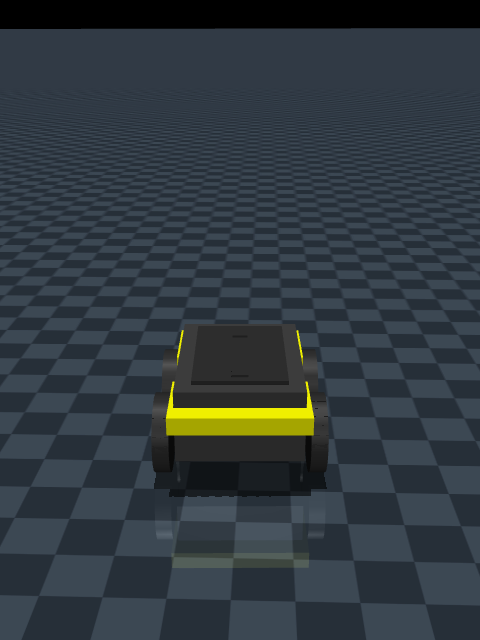

In [5]:
with mj.Renderer(model, 640, 480) as renderer:
    mj.mj_forward(model, data)
    renderer.update_scene(data, camera="track")
    pixels = renderer.render()

media.show_image(pixels)


In [6]:
# Example mjSpec edit: change the chassis top plate color, then recompile.
top_plate = next(geom for geom in spec.geoms if geom.name == "top_plate")
top_plate.rgba = [0.85, 0.25, 0.15, 1.0]

edited_model = spec.compile()
edited_xml = spec.to_xml()
edited_xml[:800]


'<mujoco model="jackal_scene_mjx_flat_terrain">\n  <compiler angle="radian"/>\n\n  <option timestep="0.004" integrator="implicitfast"/>\n\n  <visual>\n    <global offwidth="1920" offheight="1080"/>\n    <headlight ambient="0.25 0.25 0.25" diffuse="0.6 0.6 0.6" specular="0.1 0.1 0.1"/>\n    <rgba haze="0.15 0.25 0.35 1"/>\n  </visual>\n\n  <default>\n    <joint armature="0.02" damping="0.2"/>\n    <geom condim="6" friction="0.9 0.02 0.01" solref="0.004" solimp="0.95 0.99"/>\n    <general ctrllimited="true" ctrlrange="-1 1"/>\n  </default>\n\n  <asset>\n    <texture type="2d" colorspace="auto" name="groundplane" builtin="checker" rgb1="0.2 0.24 0.28" rgb2="0.13 0.16 0.19" width="512" height="512"/>\n    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="8 8" reflectance="0.1"/>\n    '